# Obesity Prevalence in West Virginia, US

## Install GAS Client SDK


In [ ]:
%pip install -q gas-client


## Imports

In [2]:
import os
from pathlib import Path
from urllib.parse import urljoin

from IPython.display import HTML, Image, display



from gas_client import GasClient

## User Settings

In [3]:
from dotenv import load_dotenv
import os
from pathlib import Path
project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent


server_url = "http://127.0.0.1:4042"
load_dotenv(project_root / ".env")
openai_api_key = os.environ["OPENAI_API_KEY"]

timeout_seconds = 900

client = GasClient(
    server_url,
    openai_api_key=openai_api_key,
    artifact_delivery="URL",
)

credentials = {"OPENAI_API_KEY": openai_api_key}

## Discover Agents

In [4]:
client.list_agents()

['exploratory_spatial_data_analysis_agent',
 'geospatial_data_inspection_agent',
 'geospatial_data_retrieval_agent',
 'geospatial_workflow_planning_agent',
 'map_projection_agent',
 'mapping_agent',
 'pasda_agent',
 'raster_agent',
 'spatial_analysis_agent',
 'spatial_statistics_agent',
 'vector_analysis_agent',
 'web_mapping_app_agent']

In [5]:
data_agent = client.agent("geospatial_data_retrieval_agent")
vector_agent = client.agent("vector_analysis_agent")
mapping_agent = client.agent("mapping_agent")
web_mapping_app_agent = client.agent("web_mapping_app_agent")
esda_agent = client.agent("exploratory_spatial_data_analysis_agent")
spatial_analysis_agent = client.agent("spatial_analysis_agent")

for agent in [data_agent, vector_agent, mapping_agent, web_mapping_app_agent, esda_agent, spatial_analysis_agent]:
    print(agent.agent_id, agent.status().get("status"))

geospatial_data_retrieval_agent available
vector_analysis_agent available
mapping_agent available
web_mapping_app_agent available
exploratory_spatial_data_analysis_agent available
spatial_analysis_agent available


## Helper Functions


In [6]:
def absolute_url(url):
    if url.startswith("/"):
        return urljoin(server_url, url)
    return url


def all_artifact_urls(task_result):
    """Return every artifact URL from a task response, in order."""
    artifacts = task_result.get("outputs", {}).get("artifacts", []) or []
    return [absolute_url(a["url"]) for a in artifacts if a.get("url")]


def first_artifact_url(task_result, preferred_extensions=None):
    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    preferred_extensions = preferred_extensions or []

    for extension in preferred_extensions:
        for artifact in artifacts:
            url = artifact.get("url")
            filename = artifact.get("filename") or artifact.get("name") or url or ""
            if url and str(filename).lower().endswith(extension.lower()):
                return absolute_url(url)

    for artifact in artifacts:
        if artifact.get("url"):
            return absolute_url(artifact["url"])

    raise RuntimeError("The task returned no artifact URL.")


def display_visual_artifacts(task_result):
    
    from urllib.request import urlopen

    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    for artifact in artifacts:
        url = artifact.get("url")
        filename = artifact.get("filename") or artifact.get("name") or ""
        if not url:
            continue
        display_url = absolute_url(url)
        lower_name = str(filename).lower()
        if lower_name.endswith((".png", ".jpg", ".jpeg", ".gif")):
            image_format = "jpeg" if lower_name.endswith((".jpg", ".jpeg")) else lower_name.rsplit(".", 1)[-1]
            try:
                with urlopen(display_url, timeout=120) as response:
                    image_bytes = response.read()
                display(Image(data=image_bytes, format=image_format))
            except Exception as exc:
                print(f"Could not embed image '{filename}' ({exc}); linking instead.")
                display(HTML(f'<a href="{display_url}" target="_blank">Open image artifact: {filename}</a>'))
        elif lower_name.endswith(".html"):
            display(HTML(f'<a href="{display_url}" target="_blank">Open interactive HTML artifact: {filename}</a>'))
        else:
            display(HTML(f'<a href="{display_url}" target="_blank">Open artifact: {filename}</a>'))


def display_geoprocessing_workflow(task_result, *, height=620):
    """Embed the Spatial Analysis agent's geoprocessing workflow DAG inline.

    The GAS server serves artifacts as downloads, so a plain <iframe src=URL> would download
    the HTML. We fetch the HTML once and embed it through an iframe srcdoc (content inlined).
    Falls back to a GraphML link if no HTML viz is available.
    """
    import html as _html
    from urllib.request import urlopen

    urls = all_artifact_urls(task_result)
    html_url = next((u for u in urls if u.lower().endswith(".html")), None)
    graphml_url = next((u for u in urls if u.lower().endswith((".graphml", ".gml"))), None)

    if html_url:
        print("Geoprocessing workflow:", html_url)
        try:
            with urlopen(html_url, timeout=120) as resp:
                doc = resp.read().decode("utf-8", errors="replace")
            srcdoc = _html.escape(doc, quote=True)
            iframe = (
                f'<iframe srcdoc="{srcdoc}" width="100%" height="{height}" '
                'style="border:1px solid #ddd; border-radius:6px;"></iframe>'
            )
            display({"text/html": iframe}, raw=True)
        except Exception as exc:
            print(f"Could not embed the workflow inline ({exc}).")
            display(HTML(f'<a href="{html_url}" target="_blank">Download the workflow HTML</a>'))
    elif graphml_url:
        display(HTML(f'<a href="{graphml_url}" target="_blank">Download the workflow GraphML</a>'))
    else:
        print("No workflow artifact (HTML or GraphML) was returned by the Spatial Analysis agent.")


def run_streaming_task(agent, instructions, *, input_datasets=None, parameters=None, title=None):
    if title:
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)

    final_result = None
    for event in agent.execute_task(
        instructions,
        mode="stream",
        input_datasets=input_datasets,
        artifact_delivery="URL",
        credentials=credentials,
        parameters=parameters,
        timeout=timeout_seconds,
    ):
        client.print_stream_event(event)
        if event.get("event") == "task_result":
            final_result = event.get("payload")

    if final_result is None:
        raise RuntimeError("The stream ended before returning a task_result event.")

    client.print_task_summary(final_result)
    return final_result

## Part 1: Download Contiguous US County Boundaries

In [7]:
county_boundary_result = run_streaming_task(
    data_agent,
    (
        "(1) Use the US Census Bureau boundary source. Download county boundaries for West Virginia."
        "Return one clean GeoPackage dataset with county geometry, county name, state name or state abbreviation, STATEFP, COUNTYFP, and GEOID fields. "
                
        "(2) Download 2020 county-leveL obesity prevalence estimates "
        "for for West Virginia. Return one clean dataset with county FIPS/GEOID, county name, "
        "state identifier, year, measure name, and the obesity prevalence value. Geometry is optional for this "
        "dataset because it will be joined to a separate county boundary dataset."
    ),
    title="Download Contiguous US County Boundaries",
)

county_boundary_url = first_artifact_url(county_boundary_result, preferred_extensions=[".gpkg", ".geojson", ".json"])
county_boundary_url


Download Contiguous US County Boundaries
[19:53:00] stream_connected: Streaming connection established.
[19:53:00] Geospatial Data Retrieval Agent: I received your request.
[19:53:01] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[19:53:01] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[19:53:01] task_accepted: Task accepted. Starting streaming execution.
[19:53:01] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[19:53:01] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[19:53:03] Geospatial Data Retrieval Agent: The request was decomposed into 2 sub-request(s).
[19:53:03] Geospatial Data Retrieval Agent: I detected 2 datasets in your request. I will download each one as a separate sub-task and return all artifacts.
[19:53

'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-8575-qmji-9404.gpkg'

In [9]:
downloaded_urls = all_artifact_urls(county_boundary_result)
county_boundary_url, obesity_url = downloaded_urls[0], downloaded_urls[1]
print("County boundaries URL:", county_boundary_url)
print("Obesity prevalence URL:", obesity_url)

County boundaries URL: http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-8575-qmji-9404.gpkg
Obesity prevalence URL: http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-3830-ewom-6178.csv


## Part 3: Join County Boundaries with Obesity Rates


In [10]:
obesity_join_result = run_streaming_task(
    vector_agent,
    (
        "Join the contiguous US county boundary dataset with the 2020 county-level adult obesity prevalence dataset. "
        "Use GEOID or county FIPS fields as the join key. Preserve county boundary geometry and key identifiers. "
        "Create a clean numeric field named obesity_rate for the obesity prevalence value. Keep county name, state, GEOID, "
        "year, and measure fields when available. Exclude unmatched non-contiguous records if present. Return one GeoJSON "
        "artifact ready for choropleth mapping."
    ),
    input_datasets=[county_boundary_url, obesity_url],
    title="Join County Boundaries and CDC Obesity Rates",
)

obesity_join_url = first_artifact_url(obesity_join_result, preferred_extensions=[".geojson", ".gpkg", ".json"])
obesity_join_url


Join County Boundaries and CDC Obesity Rates
[20:02:44] stream_connected: Streaming connection established.
[20:02:44] Vector Analysis Agent: I received your request.
[20:02:44] Vector Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 2 dataset reference(s).
[20:02:44] Vector Analysis Agent: I found the required credentials and can start the model-backed workflow.
[20:02:45] task_accepted: Task accepted. Starting streaming execution.
[20:02:45] Vector Analysis Agent: Next I will run the agent with the prepared inputs.
[20:02:45] Vector Analysis Agent: I will load the requested vector/tabular inputs, run code-driven analysis, and save a final dataset artifact from 2 dataset reference(s).
[20:02:45] Vector Analysis Agent: I detected a common vector operation and will first try a deterministic GeoPandas workflow.
[20:02:45] Vector Analysis Agent: Joined 55 spatial features with 110 table/vector records using GEOID = c

'http://127.0.0.1:4042/agents/vector_analysis_agent/data/vector_analysis_agent-3399-ejgn-6534.geojson'

## Part 4: Static Choropleth Map of County Obesity Rates



Create Static Obesity Rate Choropleth Map
[20:04:16] stream_connected: Streaming connection established.
[20:04:16] Mapping Agent: I received your request.
[20:04:17] Mapping Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[20:04:17] Mapping Agent: I found the required credentials and can start the model-backed workflow.
[20:04:17] task_accepted: Task accepted. Starting streaming execution.
[20:04:17] Mapping Agent: Next I will run the agent with the prepared inputs.
[20:04:17] Mapping Agent: I will inspect the requested visualization and the 1 dataset reference(s), then choose whether a map or chart is the best way to answer it.
[20:04:17] Mapping Agent: I am drafting visualization code now. This is attempt 1; I will run the code and check whether it creates the requested output correctly.
[20:04:27] Mapping Agent: I'm still working. Long LLM calls, code execution, or geospatial file processing ca

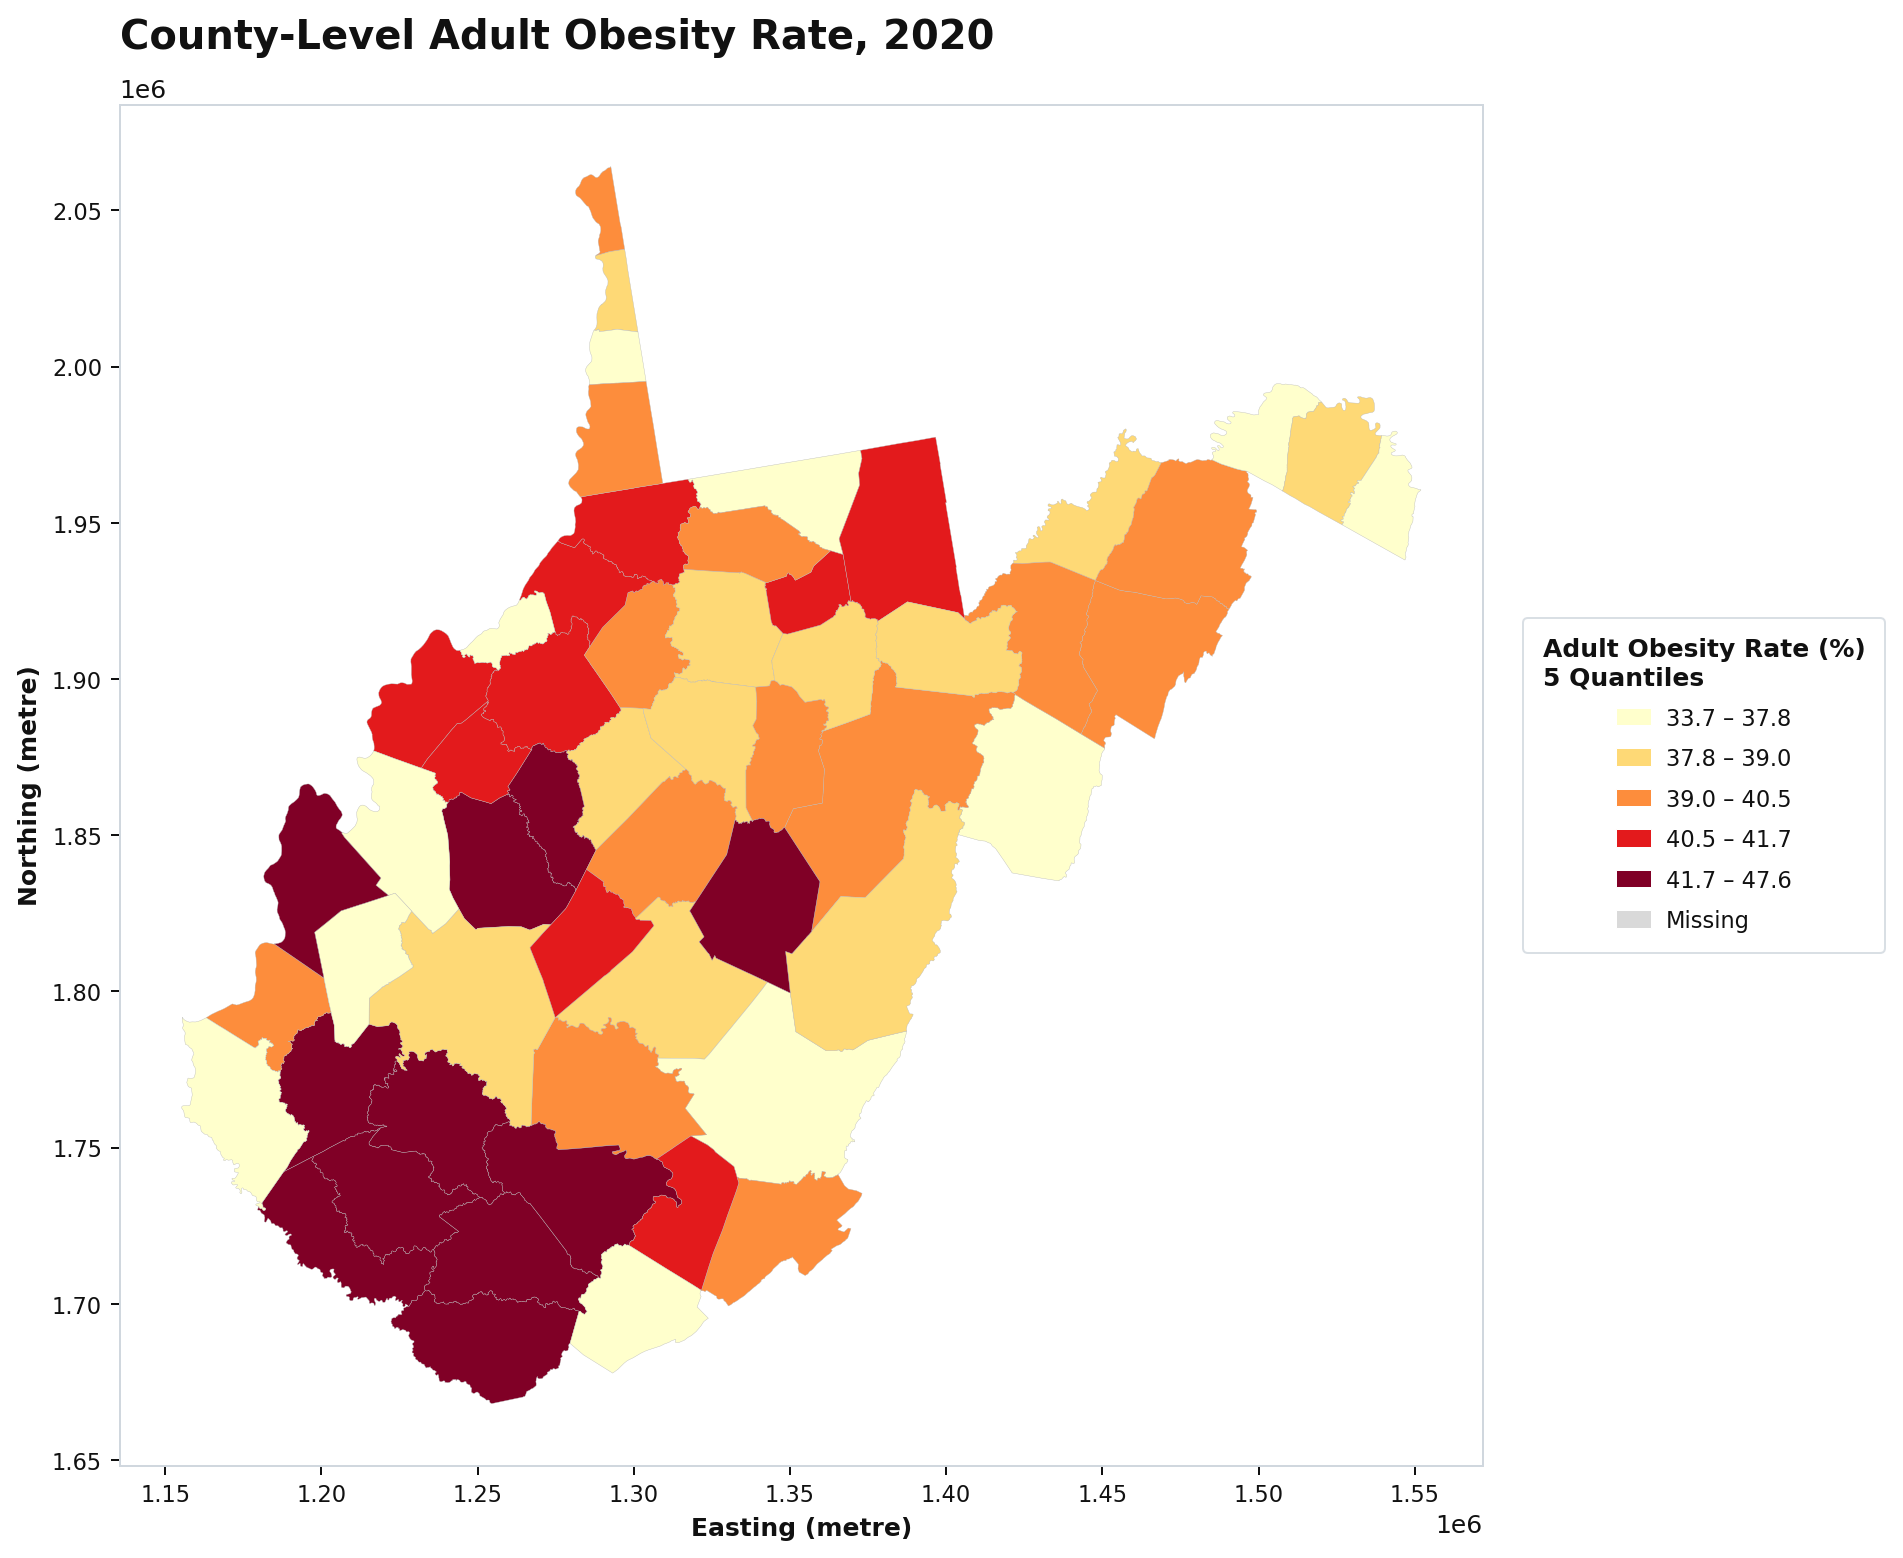

In [11]:
obesity_map_result = run_streaming_task(
    mapping_agent,
    (
        "Create a professional county-level choropleth map for the contiguous United States showing 2020 adult obesity rate. "
        "Use the obesity_rate field for color. Use 5 quantile classes, a clear sequential color scheme, thin county outlines, "
        "missing values in light gray, a legend outside the map axes, and the title 'County-Level Adult Obesity Rate, 2020'." \
        "Use the Albers Equal Area projection. " \
    ),
    input_datasets=[obesity_join_url],
    title="Create Static Obesity Rate Choropleth Map",
)

display_visual_artifacts(obesity_map_result)
